In [1]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2
using CSV
using DataFrames
using Plots.PlotMeasures

  Activating project at `~/Desktop/envs/ants`


In [28]:
function softmax(x)
    ex = exp.(x)
    return ex ./ (sum(ex))
end

function normal(x)
    return (x .+ 1) / (sum(x)+size(x)[1])
end

normal (generic function with 1 method)

In [41]:
x = [0.25,0.5,-0.2]
println(softmax(x),sum(softmax(x)))
println(normal(x),sum(normal(x)))

[0.34227192807756657, 0.4394858550703141, 0.2182422168521193]1.0
[0.35211267605633806, 0.4225352112676057, 0.22535211267605637]1.0


In [3]:
#pythonplot() # run once
#scalefontsizes(1.5) # run once

In [32]:
function model_7d!(dx,x,p,t=0)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    dx[1] = (-(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S) + gamma*H
    dx[2] = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*(1+xB)*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*(1+xT)*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    dx
end

function model_7d_softmax!(dx,x,p,t=0)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = softmax([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    dx
end

function model_7d_avg!(dx,x,p,t=0)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma,b0C,b0B,b0T)=p
    S,C,B,T,xC,xB,xT = x
    H = 1 - S - B - C - T
    xCn,xBn,xTn = normal([xC,xB,xT])
    dx[1] = (-(alphaC*xCn+alphaB*xBn+alphaT*xTn)*S) + gamma*H
    dx[2] = alphaC*xCn*S - omegaC*C/(1+ (C/k)^n)
    dx[3] = alphaB*xBn*S - omegaB*B/(1+ (C/k)^n)
    dx[4] = alphaT*xTn*S - beta*T
    dx[5] = 1/tau*(-xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C) + b0C))
    dx[6] = 1/tau*(-xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C) + b0B))
    dx[7] = 1/tau*(-xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C) + b0T))
    dx
end

model_7d_avg! (generic function with 2 methods)

### WRT $k$

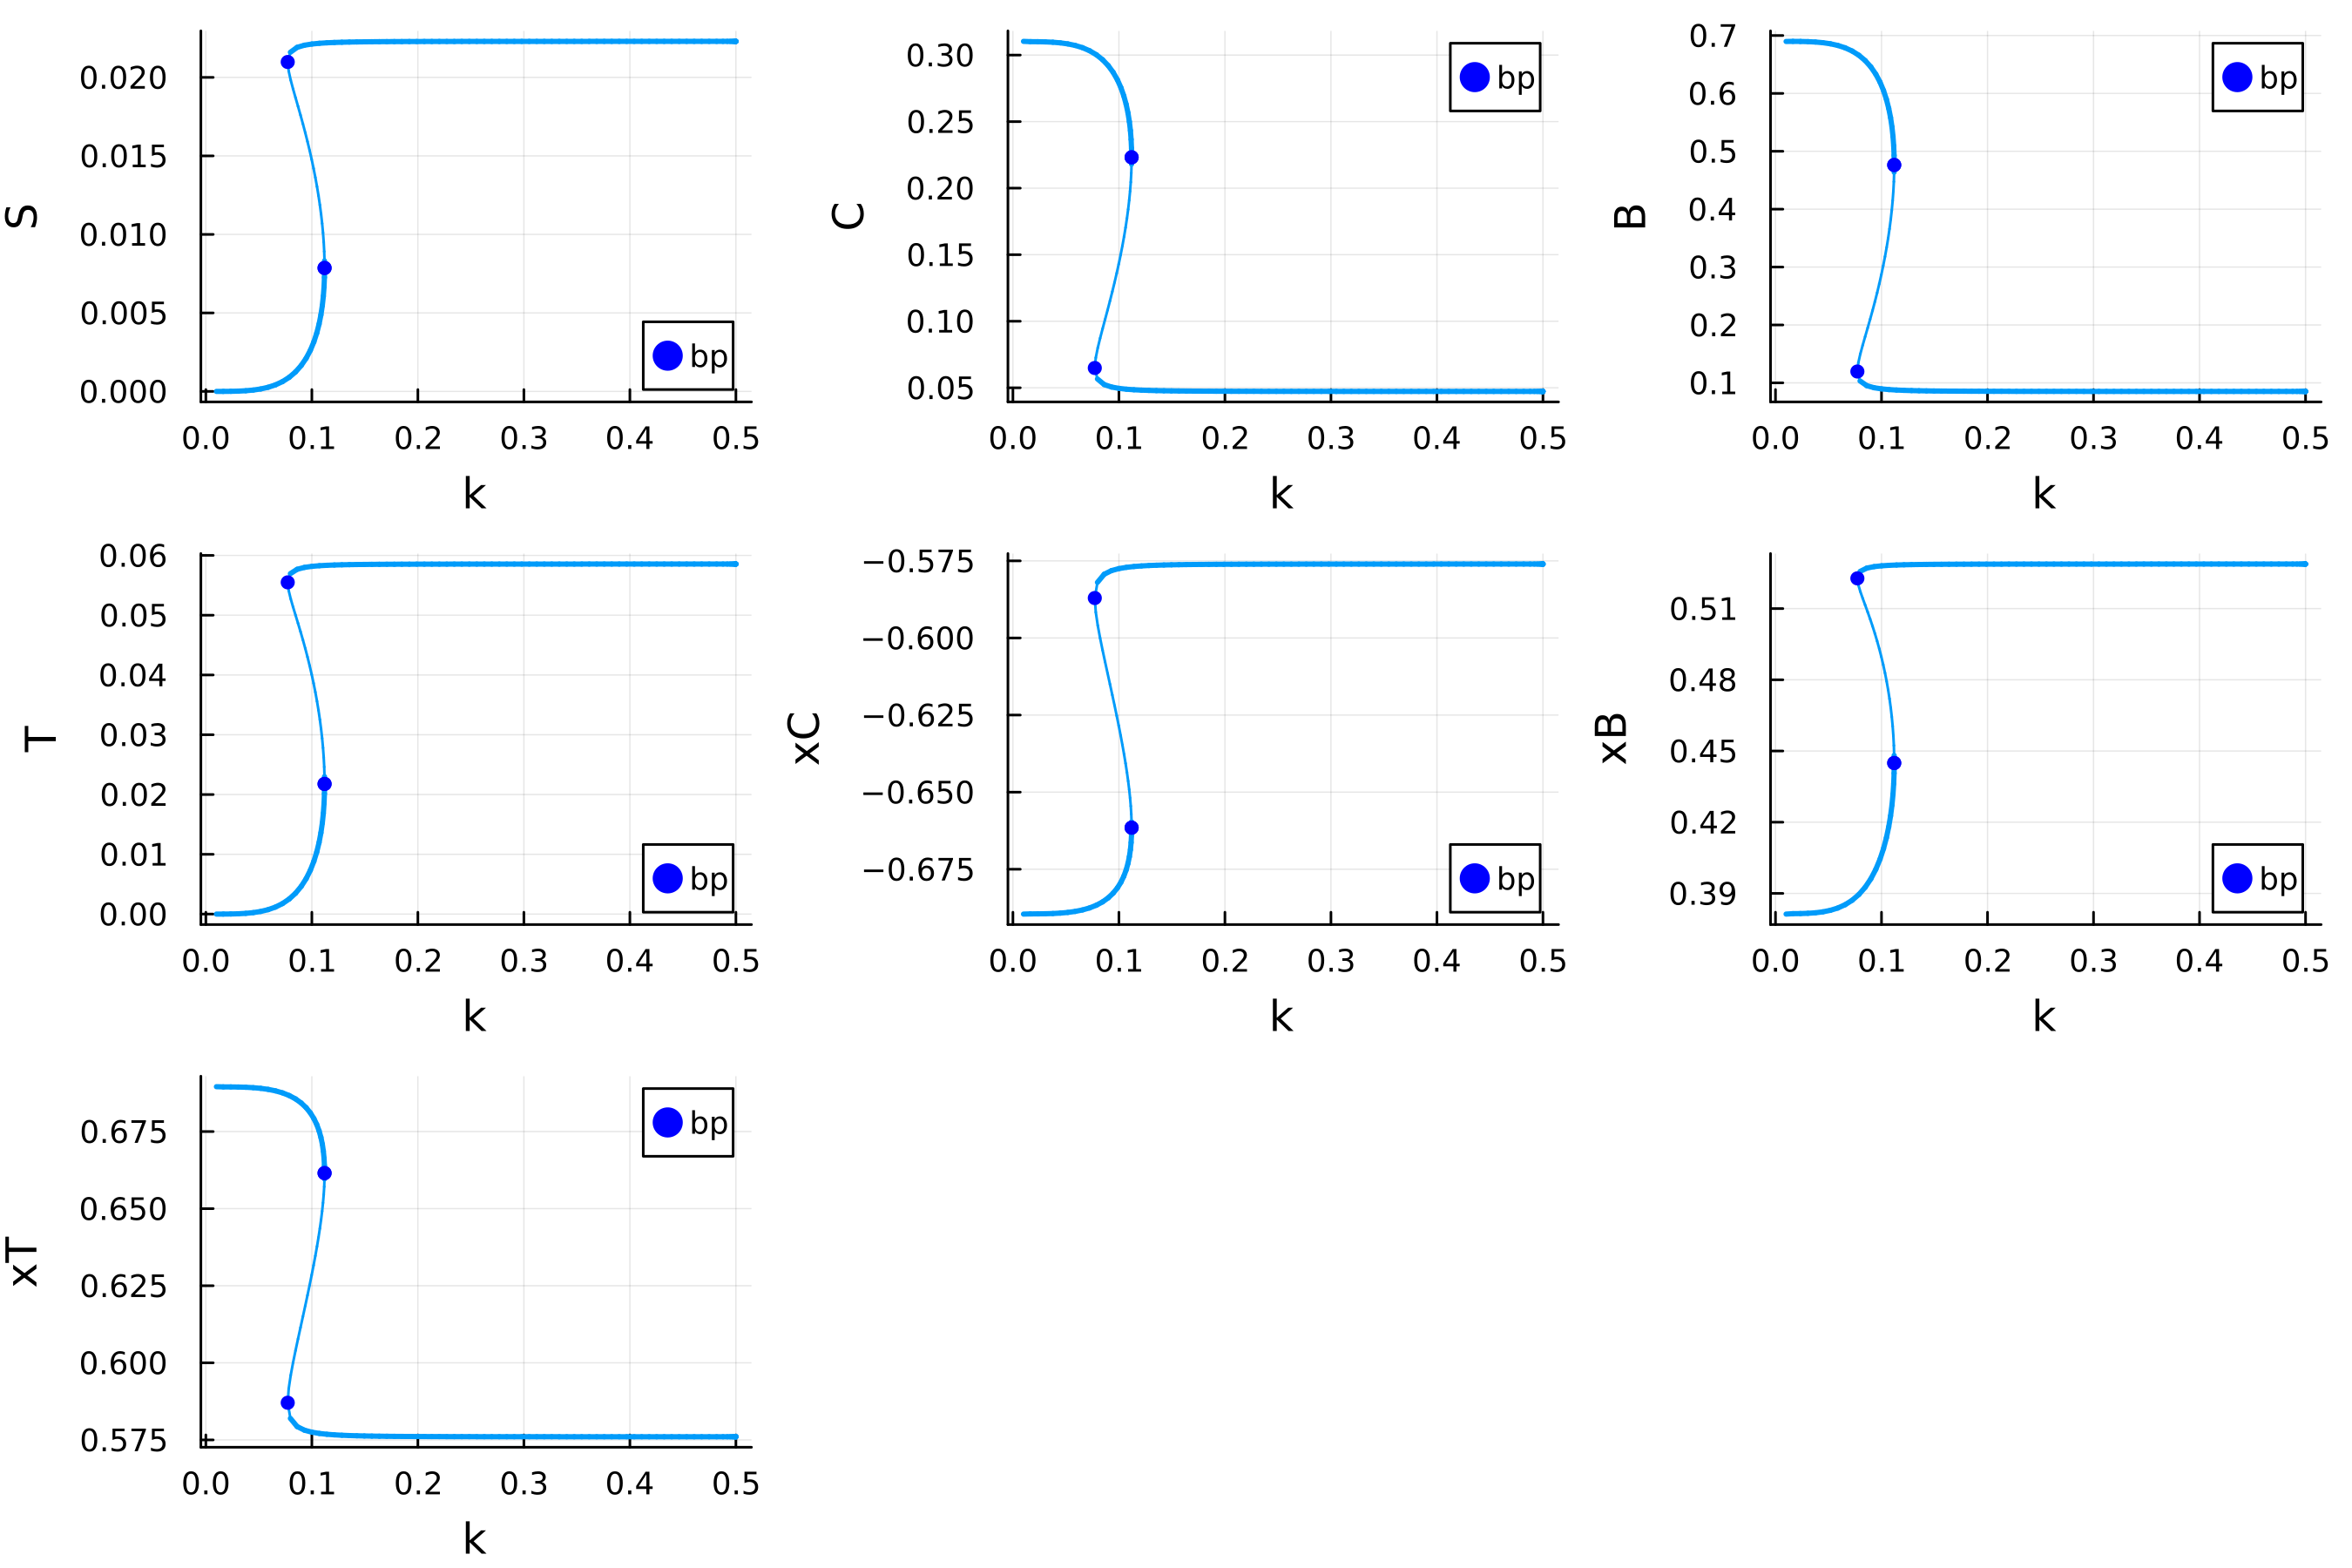

In [5]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1,b0C=0.0,b0B=0.0,b0T=0.0)
#u0 = [0.5,0.0,0.0,0.0,0.0,0.0,0.0]
u0=[0.124884391327275428,0.062413430071074756,0.12482655262389604,0.04150013222529302,-0.0006304423107703057,-0.0006278899118493966,0.0006304423107703055]

#u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]


u_bif_problem = ODEBifProblem(model_7d!, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], C = x[2], B = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]),inplace = true)

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 0.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br,bothside=true)

p1=plot(u_branch_equilibria,vars = (:param,:S))
p2 =plot(u_branch_equilibria,vars = (:param,:C))
p3=plot(u_branch_equilibria,vars = (:param,:B))
p4= plot(u_branch_equilibria,vars = (:param,:T))
p5= plot(u_branch_equilibria,vars = (:param,:xC))
p6= plot(u_branch_equilibria,vars = (:param,:xB))
p7= plot(u_branch_equilibria,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7,layout = 7,size = (900,600),dpi=300,left_margin = 2mm)
#png(FIG,"hysteresis2")

In [6]:
diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 123
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter k starts at 0.01, ends at 0.5
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at k ≈ +0.01000000,                                                                     step =   0
- #  2,       bp at k ≈ +0.11198446 ∈ (+0.11198446, +0.11198446), |δp|=4e-11, [converged], δ = ( 1,  0), step =  23
- #  3,       bp at k ≈ +0.07723857 ∈ (+0.07723857, +0.07723857), |δp|=9e-12, [converged], δ = (-1,  0), step =  46
- #  4, endpoint at k ≈ +0.50000000,                                                                     step = 122


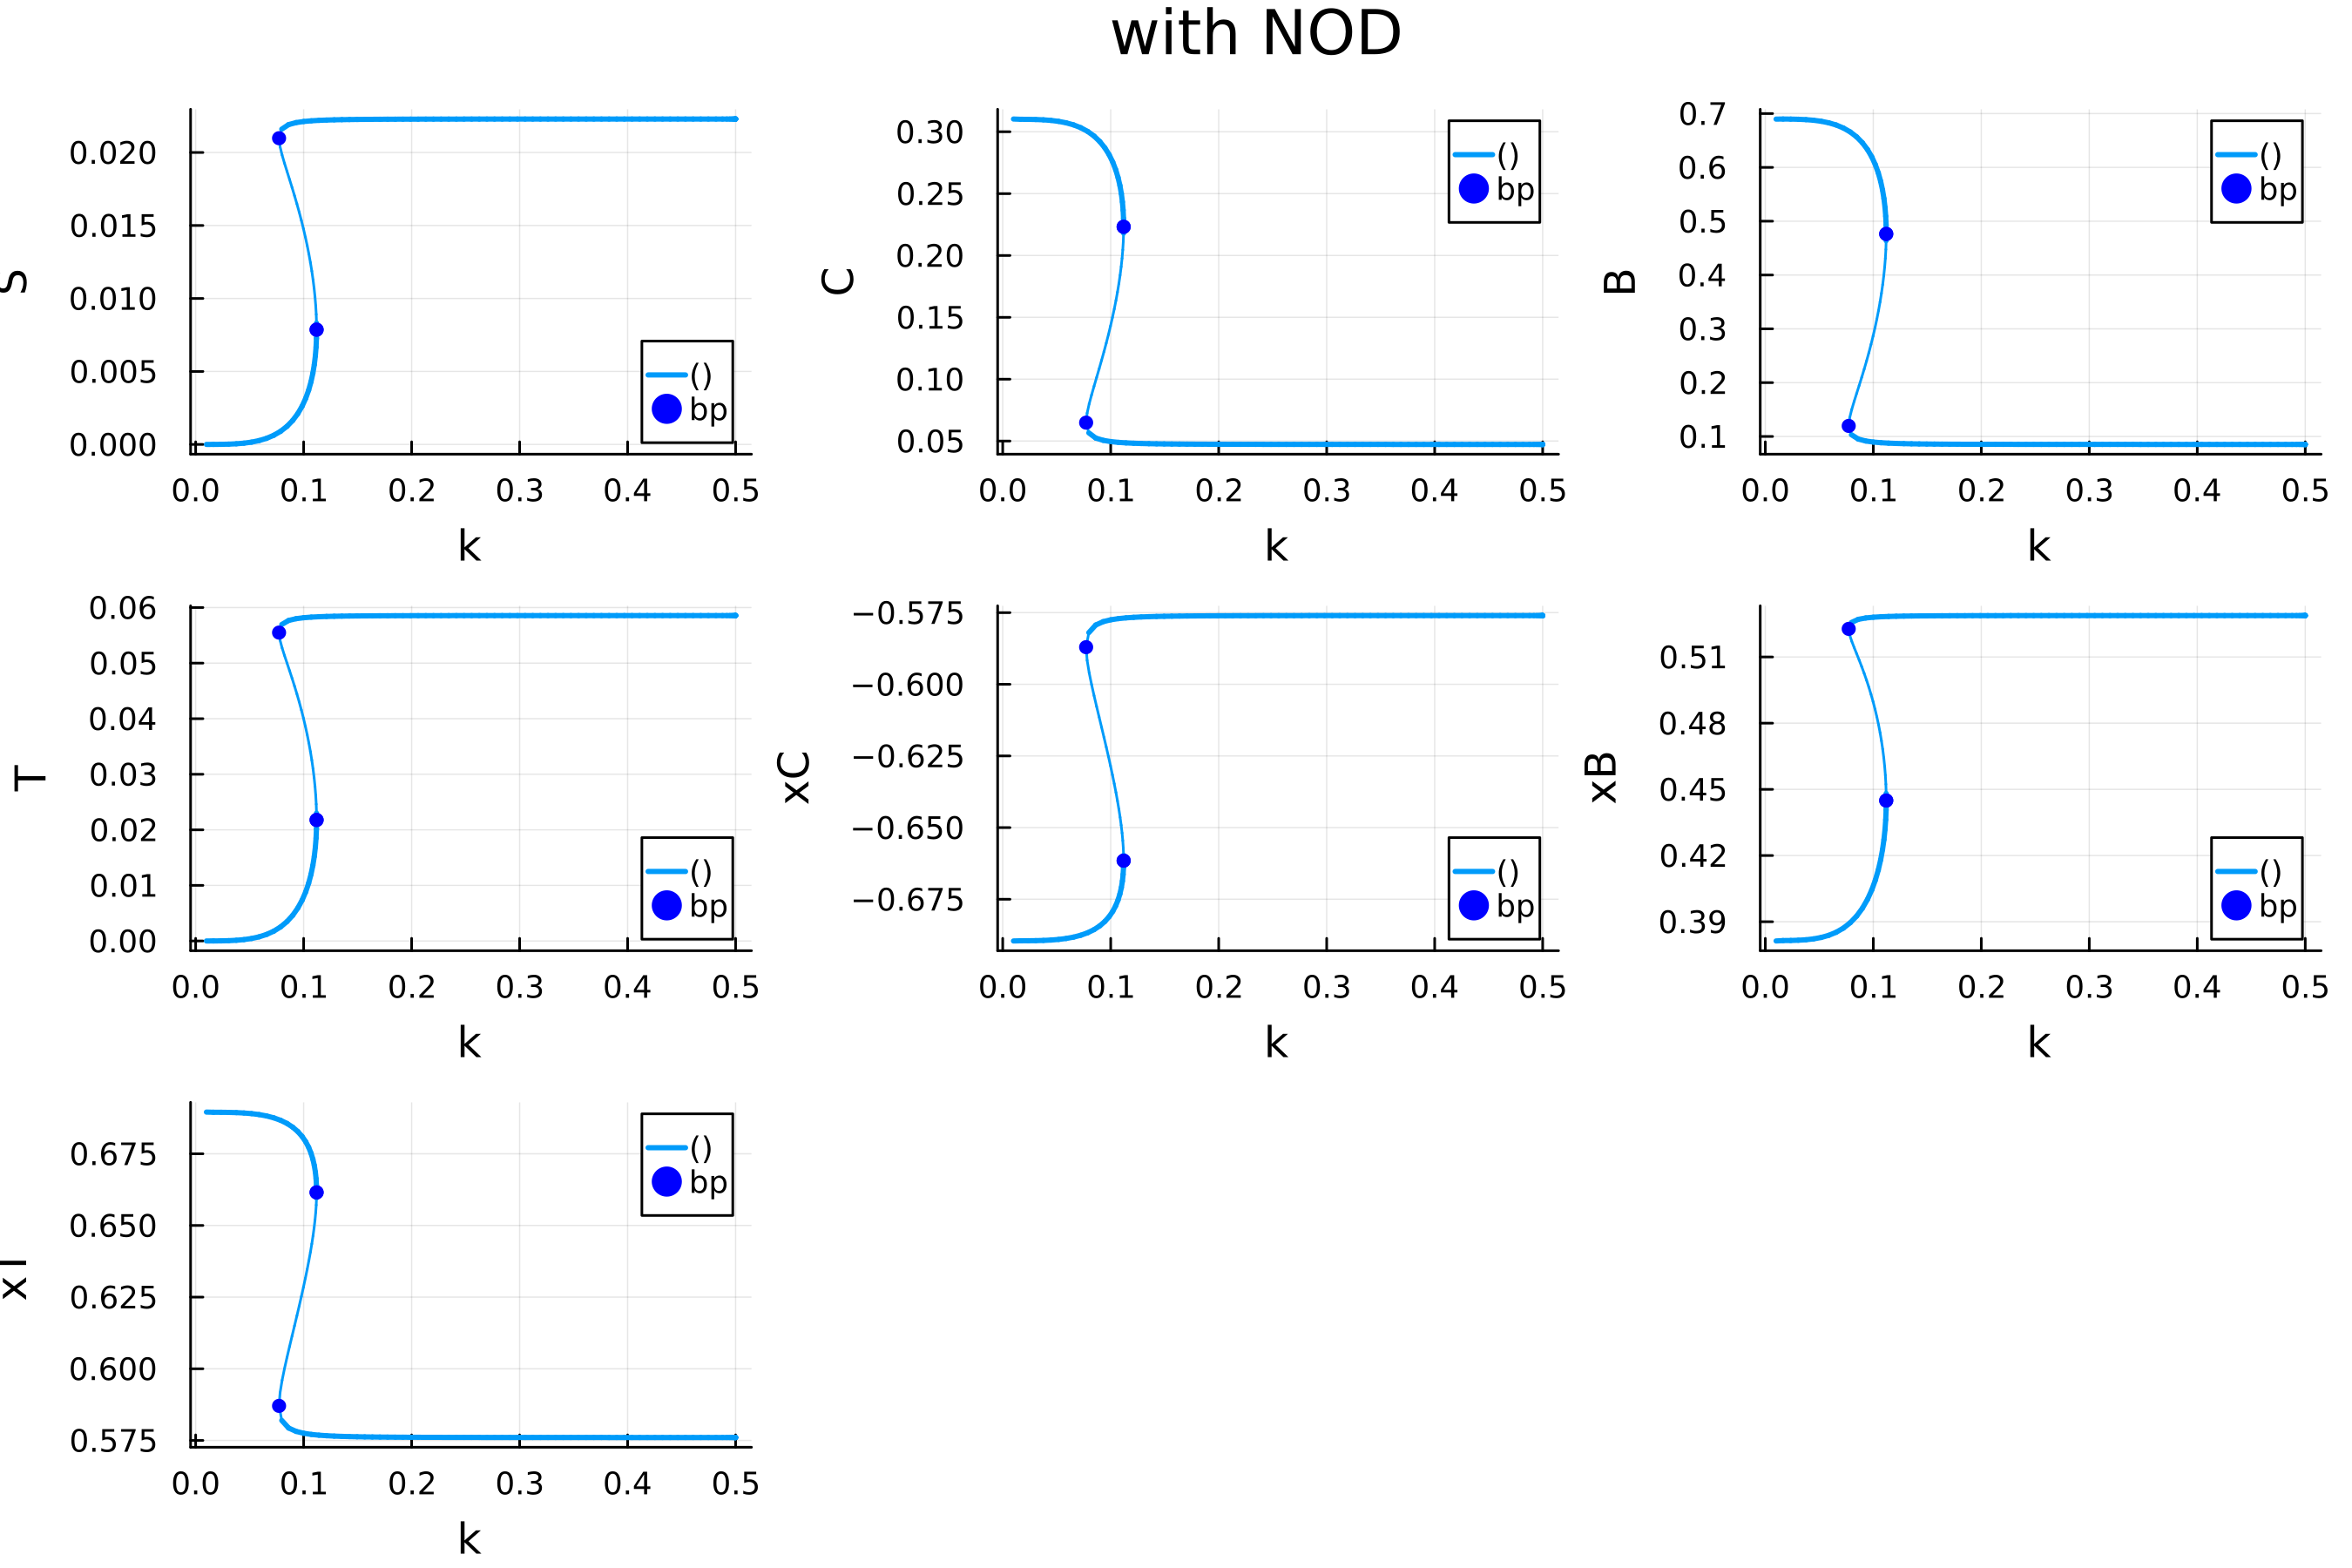

In [7]:
p1=plot(diagram,vars = (:param,:S))
p2 =plot(diagram,vars = (:param,:C))
p3=plot(diagram,vars = (:param,:B))
p4= plot(diagram,vars = (:param,:T))
p5= plot(diagram,vars = (:param,:xC))
p6= plot(diagram,vars = (:param,:xB))
p7= plot(diagram,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7, layout = 7,size = (900,600),dpi=300,suptitle = "with NOD")

In [ ]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1,b0C=0.0,b0B=0.0,b0T=0.0)
#u0 = [0.5,0.0,0.0,0.0,0.0,0.0,0.0]
u0=[0.124884391327275428,0.062413430071074756,0.12482655262389604,0.04150013222529302,-0.0006304423107703057,-0.0006278899118493966,0.0006304423107703055]

#u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]


u_bif_problem = ODEBifProblem(model_7d_avg!, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], C = x[2], B = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]),inplace = true)

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 0.5,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br,bothside=true)

p1=plot(u_branch_equilibria,vars = (:param,:S))
p2 =plot(u_branch_equilibria,vars = (:param,:C))
p3=plot(u_branch_equilibria,vars = (:param,:B))
p4= plot(u_branch_equilibria,vars = (:param,:T))
p5= plot(u_branch_equilibria,vars = (:param,:xC))
p6= plot(u_branch_equilibria,vars = (:param,:xB))
p7= plot(u_branch_equilibria,vars = (:param,:xT))
FIG = plot(p1,p2,p3,p4,p5,p6,p7,layout = 7,size = (900,600),dpi=300,left_margin = 2mm,plot_title = "normalized dynamics")
#png(FIG,"hyst_avg")

"hyst_avg.png"

## WRT $u$

In [43]:
# params from simulation in notes "u_long_continuation"
par = (alphaC=5.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
    k=0.5,n=4,u=1.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)

(alphaC = 5.0, alphaB = 1.0, alphaT = 1.0, beta = 0.6, omegaC = 0.2, omegaB = 0.4, k = 0.5, n = 4, u = 1.0, aC = 1.0, aB = 1.0, aT = 1.0, aBC = -0.2, aTC = -0.2, bC = -0.5, aCB = -0.2, aTB = 0.2, bB = -0.5, aCT = -0.2, aBT = 0.2, bT = 0.5, tau = 3, gamma = 0.1)

In [60]:
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
#    k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
#    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1,b0C=0.0,b0B=0.0,b0T=0.0) # naturally unfolds other way even without bias term?


par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.2,
    k=0.5,n=4,u=1.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1,b0C=0.0,b0B=0.0,b0T=0.0)

u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0] # S C B T
#u0 = [0.0,0.0,0.0,0.0,1.0,-1.0,-1.0]
#u0 = [0.023995803611947173,0.017729586727353117,0.24745366447632572,0.031040338110893958,0.7989832499101516,-0.7422120808348246,-0.2238570696577954]


u_bif_problem = ODEBifProblem(model_7d_avg!, u0, par, (@optic _.u),
               record_from_solution = (x, p; k...) -> (S = x[1], C = x[2], B = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]),inplace = true)

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 1.2,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 189
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 1.2, ends at 1.2
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ +1.20000000,                                                                     step =   0
- #  2,       bp at u ≈ +0.80265929 ∈ (+0.80265929, +0.80265929), |δp|=7e-12, [converged], δ = ( 1,  0), step =  87
- #  3, endpoint at u ≈ +1.20000000,                                                                     step = 188


In [61]:
#par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
#    k=0.5,n=4,u=2.0,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
#    aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1,b0C=0.0,b0B=0.0,b0T=0.0) # same as previous cell with different starting u


u0 = [0.2,0.2,0.2,0.2,0.0,0.0,0.0]
u0 = [0.0,0.0,0.0,0.0,1.0,-1.0,-1.0]
u0 = [0,0.0,0.0,0.0, -1,1,1]

u_bif_problem = ODEBifProblem(model_7d_avg!, u0, par, (@optic _.u),
               record_from_solution = (x, p; k...) -> (S = x[1], C = x[2], B = x[3], T = x[4], xC=x[5],xB=x[6],xT=x[7]),inplace = true)

opts_br = ContinuationPar(
    p_min = 0.5, p_max = 1.2,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

diagram2 = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)


[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Number of children: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 168
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 0.5, ends at 1.2
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at u ≈ +0.50000000,                                                                     step =   0
- #  2, endpoint at u ≈ +1.20000000,                                                                     step = 167


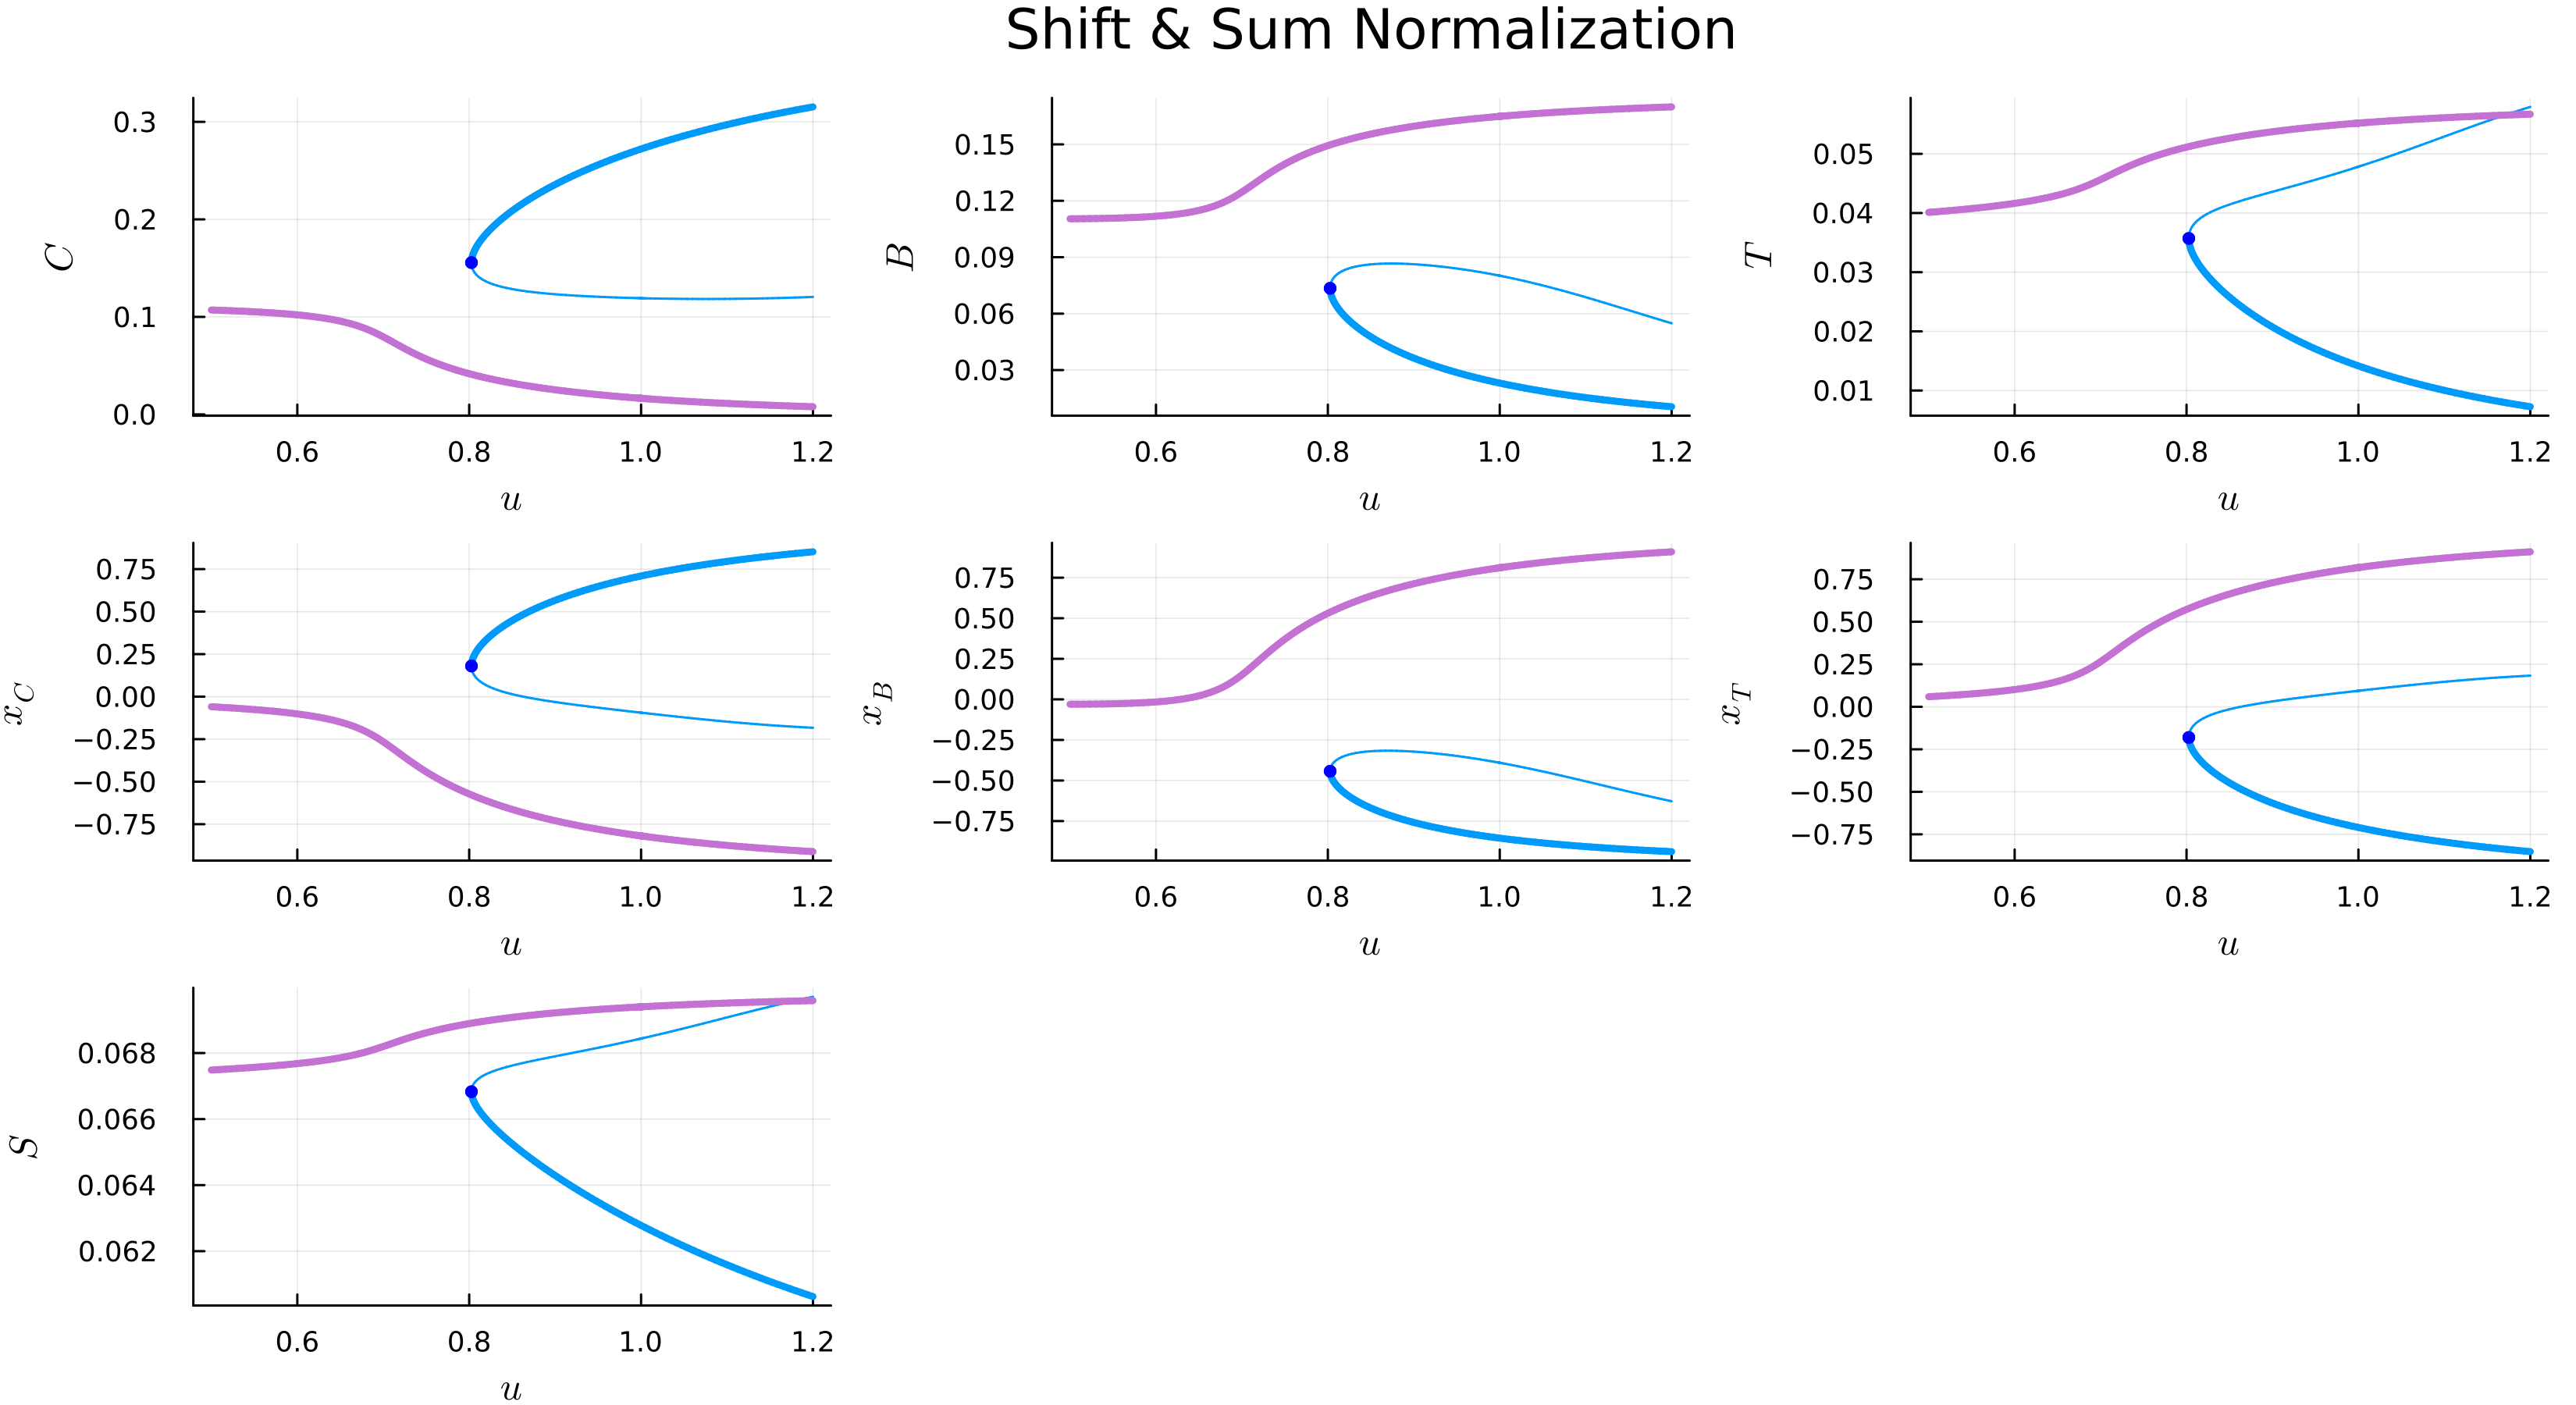

In [62]:
lws = 3
p0 = plot(diagram,vars = (:param,:S),ylabel = L"S",label ="",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:S),ylabel = L"S",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)
p1 = plot(diagram,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u",linewidthstable = lws)#,ylims = (0.1,0.2),xlims = (0.5,0.7))
plot!(diagram2,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)#,ylims = (0.1,0.2),xlims = (0.5,0.7)))
p2 = plot(diagram,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:B),ylabel = L"B",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)
p3 = plot(diagram,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)
p4 = plot(diagram,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:xC),ylabel = L"x_C",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)
p5 = plot(diagram,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:xB),ylabel = L"x_B",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)
p6 = plot(diagram,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u",linewidthstable = lws)
plot!(diagram2,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u", plotspecialpoints = false,linewidthstable = lws)

FIG = plot(p1,p2,p3,p4,p5,p6,p0, layout = 7,size = (1100,600),dpi=300,left_margin = 3mm,plot_title = "Shift & Sum Normalization")

In [11]:
#png(FIG,"u_long_continuation")